In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

import pandas as pd
import cv2
np.random.seed(42)

import feature_functions


In [34]:
texture1_path = '../data/skin texture.png'
texture2_path = '../data/skin texture 2.png'

texture1 = plt.imread(texture1_path)
texture2 = plt.imread(texture2_path)

texture1 = cv2.cvtColor(texture1, cv2.COLOR_RGBA2RGB)
texture1 = (texture1*255).astype('uint8')
texture2 = (texture2*255).astype('uint8')

In [72]:
def shape_mask(shape, kind='triangle', size_ratio=0.5):
    h, w = shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # Calculate the bounding box for the shape
    side = int(min(h, w) * size_ratio)
    center = (w // 2, h // 2)

    if kind == 'triangle':
        # Vertices for an upright triangle
        pts = np.array([
            [center[0], center[1] - side // 2],
            [center[0] - side // 2, center[1] + side // 2],
            [center[0] + side // 2, center[1] + side // 2]
        ], np.int32)
        cv2.fillPoly(mask, [pts], 1)
    elif kind == 'square':
        top_left = (center[0] - side // 2, center[1] - side // 2)
        bottom_right = (center[0] + side // 2, center[1] + side // 2)
        cv2.rectangle(mask, top_left, bottom_right, 1, -1)
    elif kind == 'circle':
        radius = int(side // 2)
        cv2.circle(mask, center, radius, 1, -1)
    else:
        raise ValueError("kind must be 'triangle', 'square', or 'circle'")

    return mask

def compute_features(masked_hand):
    X = {}
    input_features = ['redness', 'lbp_glcm','hessian',] # 'pyfeats',]

    for input_feature in input_features:
        computed_features = feature_functions.feature_delegation(input_feature,masked_hand)
        X.update(computed_features)

    computed_features = pd.Series(X)
    return computed_features


In [ ]:
def compare_masks(texture):
    triangle_mask = shape_mask(texture.shape[:2], 'triangle', size_ratio=1)
    triangle_mask2 = shape_mask(texture.shape[:2], 'triangle', size_ratio=0.5)
    square_mask = shape_mask(texture.shape[:2], 'square', size_ratio=1)
    square_mask2 = shape_mask(texture.shape[:2], 'square', size_ratio=0.5)
    circle_mask = shape_mask(texture.shape[:2], 'circle', size_ratio=1)
    circle_mask2 = shape_mask(texture.shape[:2], 'circle', size_ratio=0.5)

    X = {}
    for mask, title in zip(
        [None, triangle_mask, triangle_mask2, square_mask, square_mask2, circle_mask, circle_mask2],
        ['Original Image', 'Triangle Full', 'Triangle Half', 'Square Full', 'Square Half', 'Circle Full', 'Circle Half']
    ):
        if mask is None:
            masked_hand = texture
        else:
            masked_hand = np.where(mask[..., None], texture, 0)
        s = compute_features(masked_hand)
        plt.imshow(masked_hand)
        plt.title(title)
        plt.axis('off')
        plt.show()
        X[title] = s
    return pd.DataFrame(X).T

/Users/ntin/DermaML/.venv/lib/python3.11/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/Users/ntin/DermaML/src/dermaml/features.py:210: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = hessian_matrix(gray, sigma=sigma)


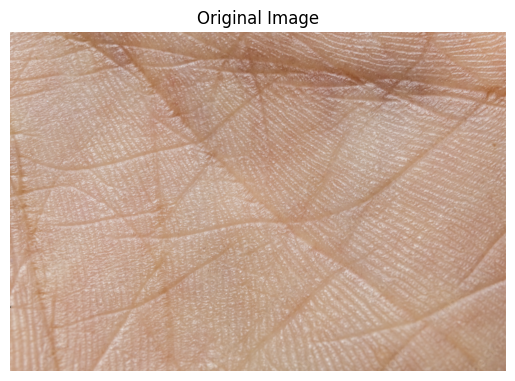

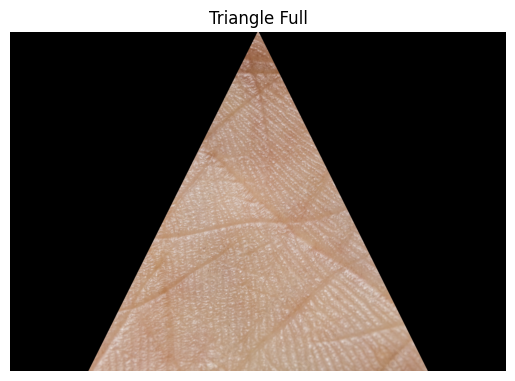

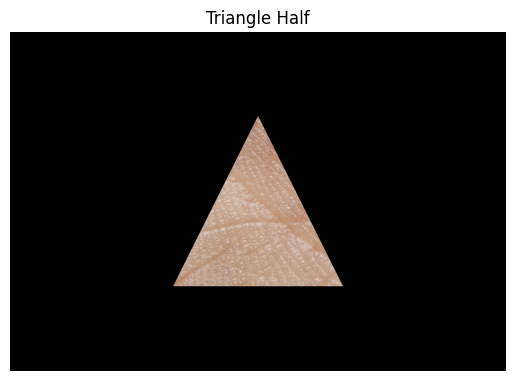

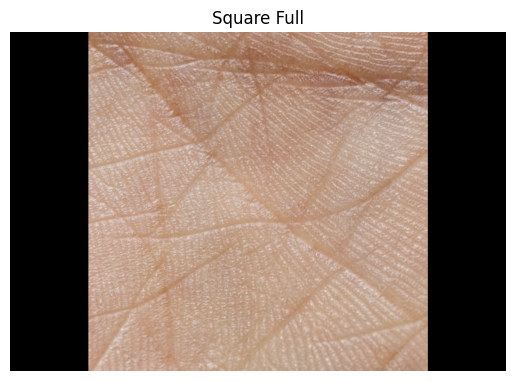

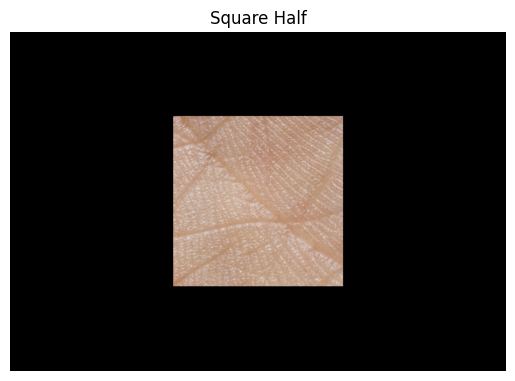

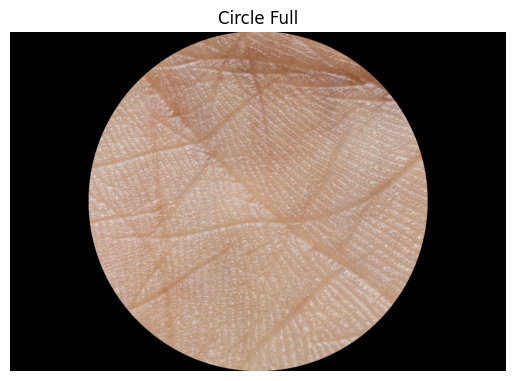

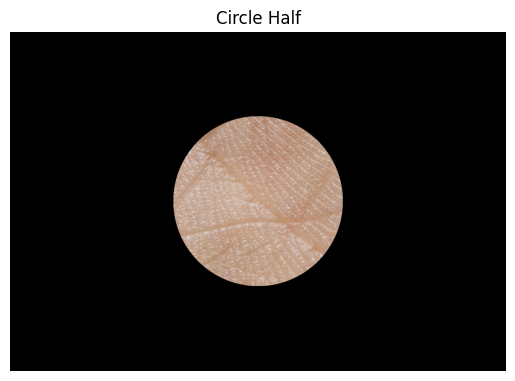

In [79]:
features_hand1 = compare_masks(texture1)

In [77]:
features_hand1

,relative_redness_mean,relative_redness_std,lbp_0,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9,lbp_10,contrast_scikit,correlation_scikit,energy_scikit,homogeneity_scikit,skin_folds_hessian,skin_folds_hessian_pct_mask
Original Image,0.791960,2.437567,0.045596,0.053814,0.068758,0.083957,0.145372,0.178951,0.119528,0.076232,0.042160,0.042535,0.143098,53.440045,0.776888,0.035786,0.184170,113088.0,0.048105
Triangle Full,0.781562,2.117768,0.015681,0.018103,0.023923,0.030021,0.048849,0.061148,0.043649,0.025799,0.013109,0.671904,0.047814,30.565252,0.966559,0.654006,0.715634,97695.0,0.121333
Triangle Half,0.775284,1.970740,0.004737,0.005244,0.006346,0.007035,0.010226,0.012834,0.010464,0.007090,0.003748,0.918189,0.014088,10.995878,0.964502,0.912528,0.927190,65863.0,0.326167
Square Full,0.795860,2.515222,0.032125,0.037132,0.047754,0.057848,0.095617,0.119551,0.083959,0.052759,0.028186,0.345417,0.099652,49.354299,0.950498,0.311886,0.432645,117111.0,0.072781
Square Half,0.782964,2.004079,0.009295,0.010272,0.012567,0.013896,0.020639,0.025880,0.020985,0.014146,0.007602,0.836753,0.027965,16.365177,0.970696,0.826685,0.855038,97213.0,0.241089
Circle Full,0.791325,2.486906,0.026218,0.030051,0.038190,0.045202,0.071704,0.089021,0.065727,0.042278,0.022850,0.487349,0.081412,42.572517,0.960230,0.459107,0.552181,109735.0,0.086905
Circle Half,0.779953,2.006243,0.007439,0.008148,0.009824,0.010805,0.015895,0.019709,0.016305,0.011181,0.006025,0.872339,0.022330,14.470696,0.968214,0.864029,0.885871,88010.0,0.278819


/Users/ntin/DermaML/.venv/lib/python3.11/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/Users/ntin/DermaML/src/dermaml/features.py:210: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = hessian_matrix(gray, sigma=sigma)


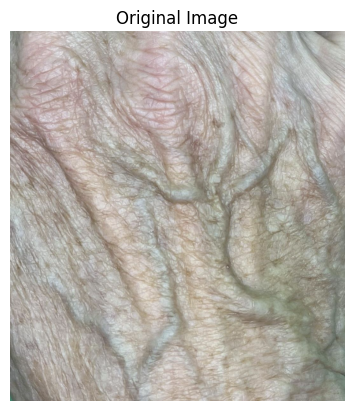

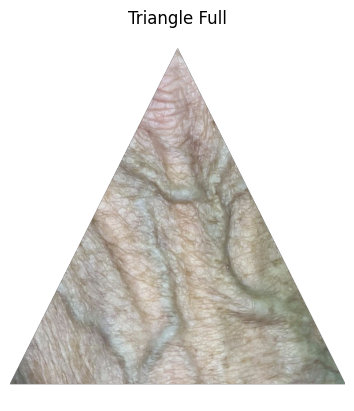

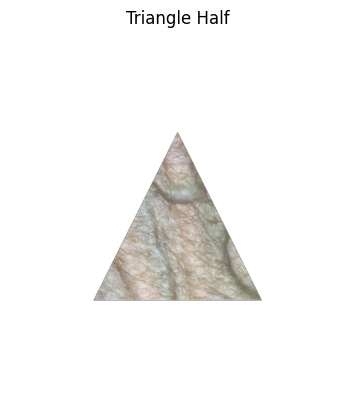

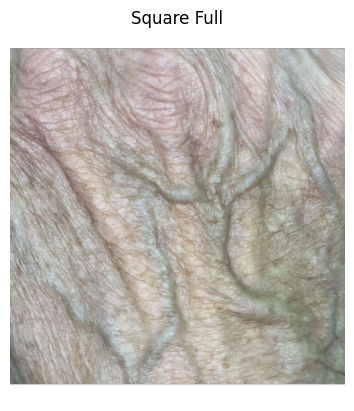

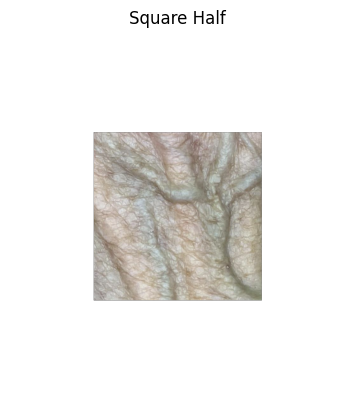

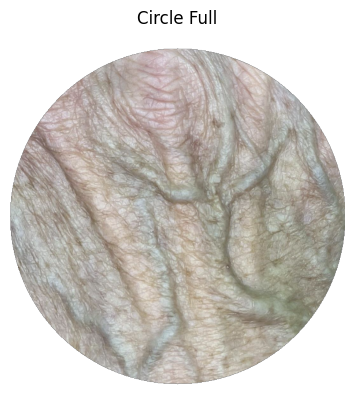

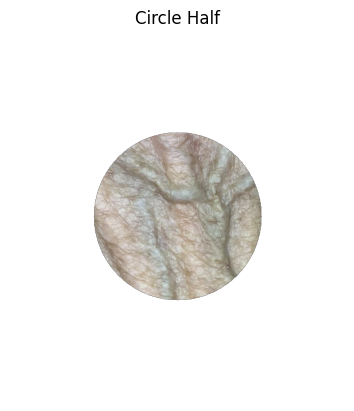

In [80]:
features_hand2 = compare_masks(texture2)

In [82]:
features_hand2

,relative_redness_mean,relative_redness_std,lbp_0,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9,lbp_10,contrast_scikit,correlation_scikit,energy_scikit,homogeneity_scikit,skin_folds_hessian,skin_folds_hessian_pct_mask
Original Image,0.729574,2.855928,0.064696,0.069615,0.064275,0.074725,0.108526,0.112185,0.075145,0.059569,0.070024,0.079011,0.222228,38.445046,0.629375,0.053330,0.267458,14813.0,0.039906
Triangle Full,0.726056,2.649065,0.026635,0.031008,0.031255,0.037120,0.054426,0.056449,0.036110,0.027336,0.029340,0.575560,0.094760,21.321573,0.895324,0.533488,0.653485,17209.0,0.101786
Triangle Half,0.714260,2.147366,0.006296,0.007775,0.008486,0.010000,0.014723,0.015342,0.009370,0.007012,0.006463,0.892182,0.022352,7.017908,0.915908,0.880643,0.906981,14215.0,0.334581
Square Full,0.730840,2.901789,0.058583,0.063179,0.058664,0.068400,0.099071,0.102099,0.068303,0.054205,0.063015,0.163316,0.201166,34.824408,0.755142,0.104138,0.331921,15490.0,0.045967
Square Half,0.723617,2.200111,0.012996,0.015213,0.016123,0.019186,0.028351,0.029949,0.018742,0.014089,0.013583,0.786083,0.045684,11.972234,0.913806,0.766021,0.818906,17771.0,0.209858
Circle Full,0.727326,2.789047,0.044863,0.049238,0.047010,0.054515,0.079954,0.082468,0.054811,0.042885,0.047678,0.341053,0.155525,31.255832,0.840264,0.278838,0.455889,16162.0,0.061176
Circle Half,0.725893,2.225122,0.009806,0.011619,0.012928,0.015224,0.022869,0.023564,0.014725,0.010865,0.010463,0.832772,0.035164,10.467668,0.912604,0.816643,0.855874,16476.0,0.249466
